# 02 — Capacidade de Consumo e Dinamismo Econômico

**Objetivo**: analisar renda, PIB, volume Pix e dinamismo financeiro dos municípios.

**Inputs**: `data/processed/trusted_municipios_eda.parquet`, `raw_bcb_pix_transacoes`.

**Outputs**: figuras e tabela de estatísticas por estrato populacional.

In [1]:
# Imports
import logging

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.config import PROCESSED_DATA_DIR
from src.utils.bigquery import read_table_to_dataframe
from src.utils.eda import plot_boxplot_by_group, plot_distribution, save_figure, save_json

logging.basicConfig(
    level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s"
)
logger = logging.getLogger(__name__)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

In [2]:
# Leitura
df = pd.read_parquet(PROCESSED_DATA_DIR / "trusted_municipios_eda.parquet")
df_raw_pix = read_table_to_dataframe("raw_bcb_pix_transacoes")
logger.info("trusted: %s, raw_pix: %s", df.shape, df_raw_pix.shape)

2026-09-03 12:18:31,889 - INFO - trusted: (5570, 32), raw_pix: (72421, 21)


## 1. Distribuição de PIB e Pix per capita (escala log)

/home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


2026-09-03 12:18:33,125 - INFO - Figura salva em /home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/docs/assets/figures/02_dist_log_pib_per_capita.png


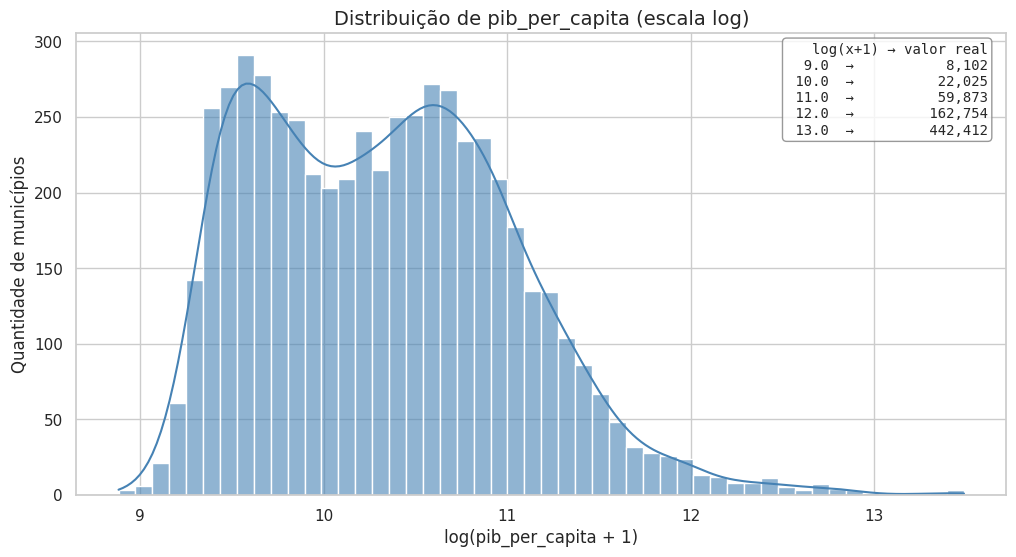

/home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


2026-09-03 12:18:34,490 - INFO - Figura salva em /home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/docs/assets/figures/02_dist_log_pix_per_capita.png


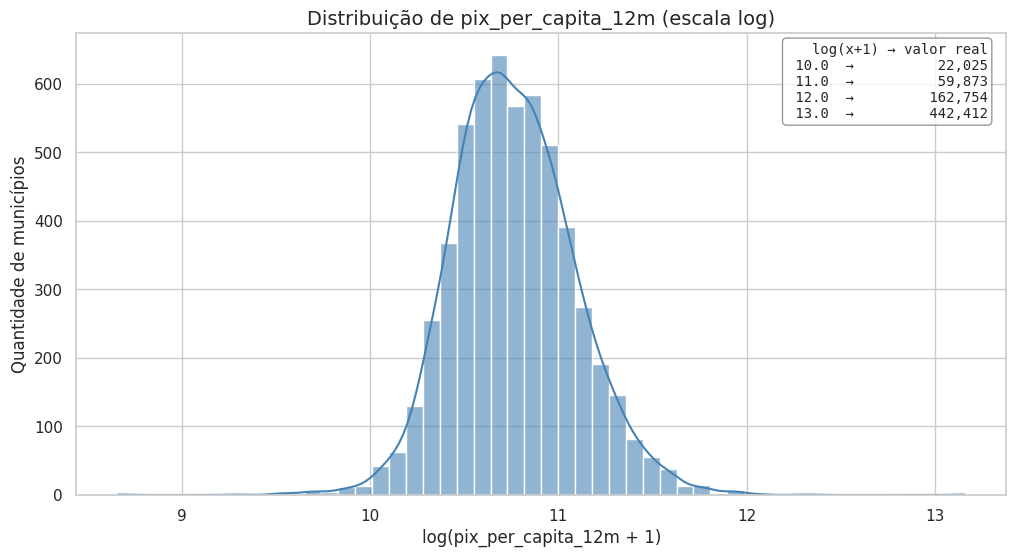

In [3]:
# Distribuição de PIB e Pix per capita (escala log)
# As variáveis são fortemente assimétricas, então usamos log(x+1) para visualizar.
# A tabela no canto superior direito converte valores do eixo X em R$ reais.
# O Pix per capita é a variável central do pilar B: mede adoção digital transacional.

log_refs = {
    "pib_per_capita": [9.0, 10.0, 11.0, 12.0, 13.0],
    "pix_per_capita_12m": [10.0, 11.0, 12.0, 13.0],
}

filenames = {
    "pib_per_capita": "02_dist_log_pib_per_capita.png",
    "pix_per_capita_12m": "02_dist_log_pix_per_capita.png",
}

for col in ["pib_per_capita", "pix_per_capita_12m"]:
    plot_distribution(
        df,
        col,
        log_scale=True,
        log_ref_vals=log_refs[col],
        filename=filenames[col],
    )
    plt.show()


## 2. Sazonalidade e evolução do Pix

2026-09-03 12:18:36,113 - INFO - Figura salva em /home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/docs/assets/figures/02_serie_pix.png


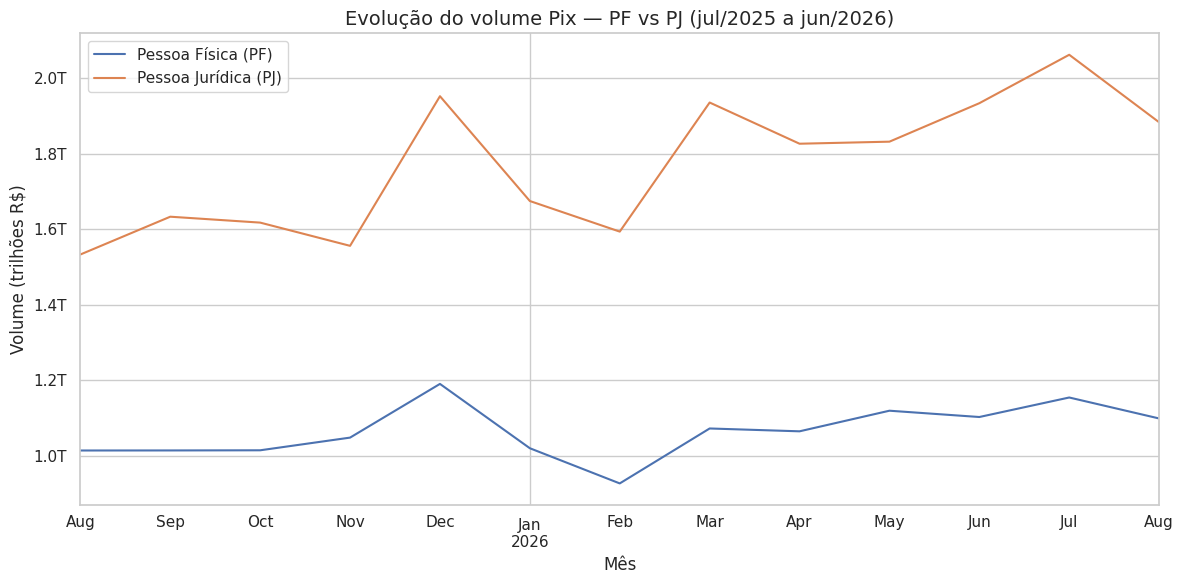

In [4]:
# Evolução do volume Pix (PF vs PJ)
# Dados brutos do BCB. O eixo Y mostra o volume total movimentado no mês,
# em trilhões de reais (R$). PJ já está nos dados brutos, mas a camada trusted
# do IPB utiliza apenas PF como proxy de adoção digital.

df_raw_pix["ano_mes"] = pd.to_datetime(
    df_raw_pix["AnoMes"].astype(str), format="%Y%m"
)

serie = (
    df_raw_pix.groupby("ano_mes")
    .agg(
        VL_PagadorPF=("VL_PagadorPF", "sum"),
        VL_PagadorPJ=("VL_PagadorPJ", "sum"),
    )
    .reset_index()
    .sort_values("ano_mes")
)

fig, ax = plt.subplots(figsize=(12, 6))
serie.plot(x="ano_mes", y=["VL_PagadorPF", "VL_PagadorPJ"], ax=ax)

ax.set_title("Evolução do volume Pix — PF vs PJ (jul/2025 a jun/2026)", fontsize=14)
ax.set_xlabel("Mês", fontsize=12)
ax.set_ylabel("Volume (trilhões R$)", fontsize=12)
ax.legend(["Pessoa Física (PF)", "Pessoa Jurídica (PJ)"], loc="upper left")

# Formatar eixo Y em trilhões
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x / 1e12:.1f}T")
)

plt.tight_layout()
save_figure(fig, "02_serie_pix.png")
plt.show()


## 3. Estatísticas por estrato populacional

In [5]:
stats = (
    df.groupby("estrato_populacional")
    .agg(
        rendimento_domiciliar_per_capita=("rendimento_domiciliar_per_capita", "median"),
        pib_per_capita=("pib_per_capita", "median"),
        pix_per_capita_12m=("pix_per_capita_12m", "median"),
    )
    .round(2)
)
display(stats)

/tmp/ipykernel_1344039/4291856.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("estrato_populacional")


,rendimento_domiciliar_per_capita,pib_per_capita,pix_per_capita_12m
estrato_populacional,,,
pequena,1145.36,28216.86,44655.74
media,1460.71,42068.32,61497.72
grande,2079.68,56227.29,83289.65


## 4. Boxplots por estrato

/home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/.venv/lib/python3.11/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


2026-09-03 12:18:37,812 - INFO - Figura salva em /home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/docs/assets/figures/02_boxplot_rendimento_domiciliar_per_capita_estrato.png


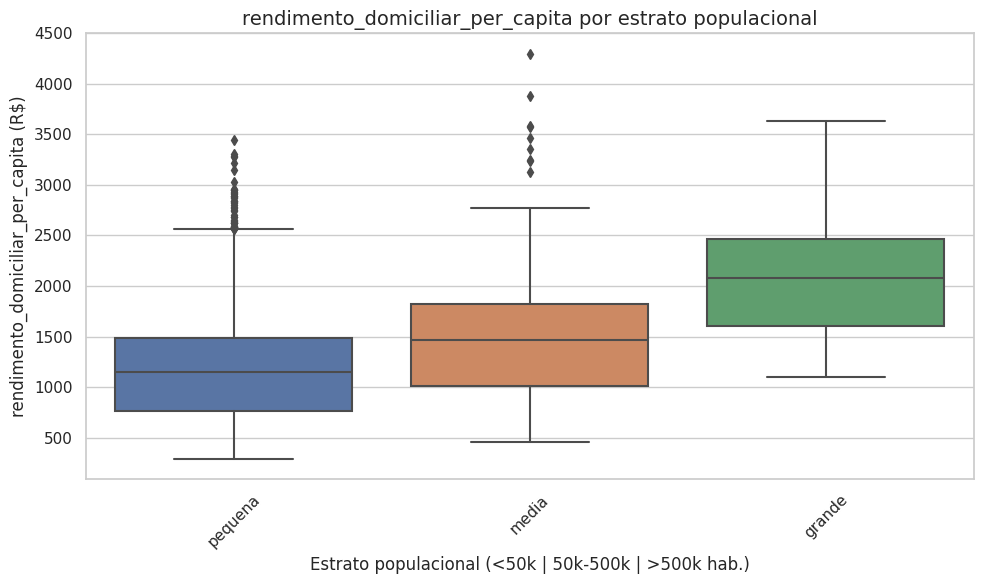

/home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/.venv/lib/python3.11/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


2026-09-03 12:18:39,242 - INFO - Figura salva em /home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/docs/assets/figures/02_boxplot_pib_per_capita_estrato.png


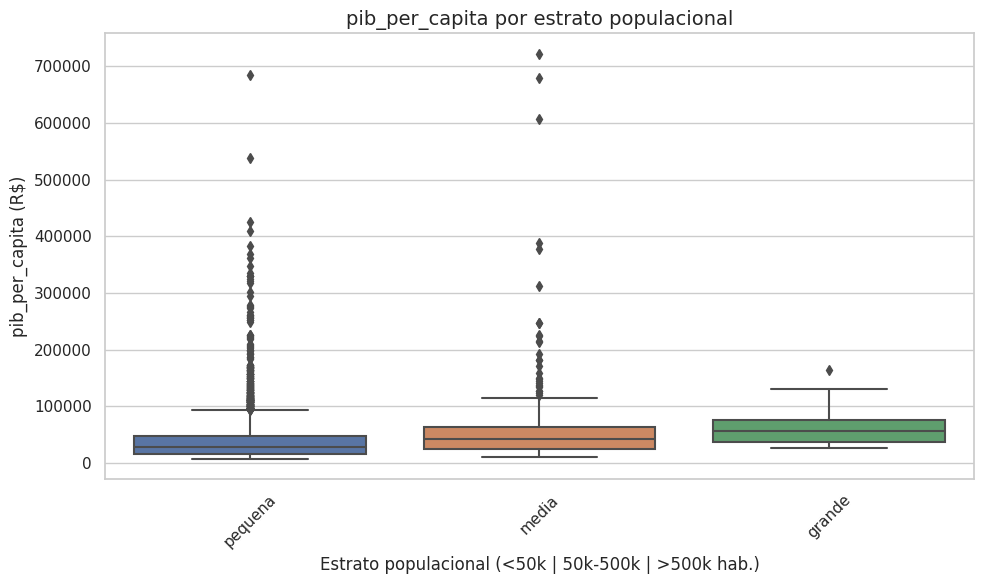

/home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/.venv/lib/python3.11/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


2026-09-03 12:18:40,703 - INFO - Figura salva em /home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/docs/assets/figures/02_boxplot_pix_per_capita_12m_estrato.png


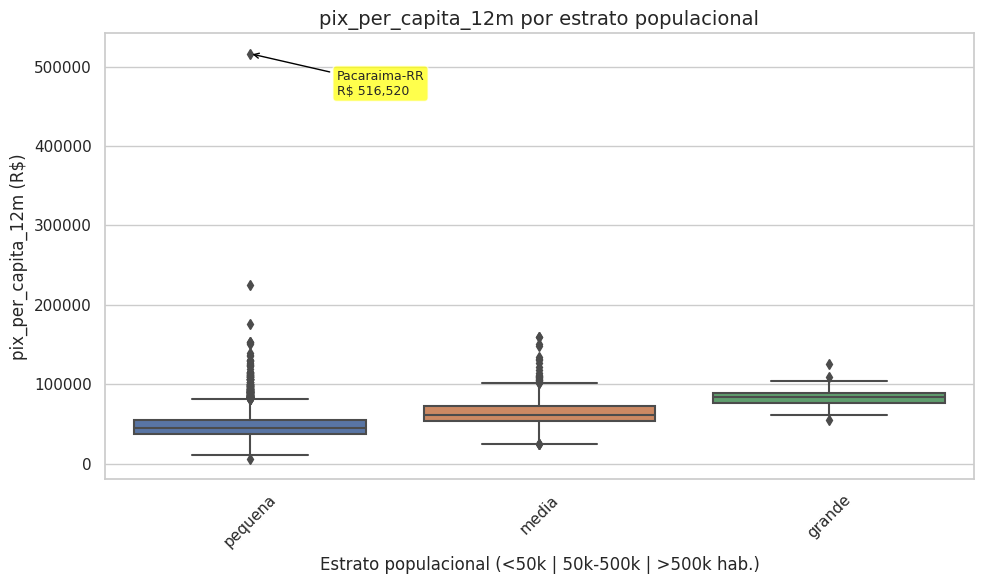

In [6]:
# Boxplots por estrato populacional
# Estratificação:
#   - pequena: < 50 mil habitantes
#   - média:   50 mil a 500 mil habitantes
#   - grande:  > 500 mil habitantes

for col in ["rendimento_domiciliar_per_capita", "pib_per_capita", "pix_per_capita_12m"]:
    fig, ax = plt.subplots(figsize=(10, 6))
    order = ["pequena", "media", "grande"]
    sns.boxplot(data=df, x="estrato_populacional", y=col, ax=ax, order=order)
    ax.set_title(f"{col} por estrato populacional", fontsize=14)
    ax.set_xlabel("Estrato populacional (<50k | 50k-500k | >500k hab.)", fontsize=12)
    ax.set_ylabel(f"{col} (R$)", fontsize=12)
    ax.tick_params(axis="x", rotation=45)

    # Destacar o outlier de Pix entre os municípios pequenos
    if col == "pix_per_capita_12m":
        outlier = df[df["estrato_populacional"] == "pequena"].nlargest(1, col).iloc[0]
        ax.annotate(
            f"{outlier['nome_municipio']}-{outlier['sigla_uf']}\nR$ {outlier[col]:,.0f}",
            xy=(0, outlier[col]),
            xytext=(0.3, outlier[col] * 0.9),
            arrowprops=dict(arrowstyle="->", color="black"),
            fontsize=9,
            bbox=dict(boxstyle="round", facecolor="yellow", alpha=0.7),
        )

    plt.tight_layout()
    save_figure(fig, f"02_boxplot_{col}_estrato.png")
    plt.show()


## 5. Municípios com alta adoção Pix e baixa renda

Quadrantes formados pelas medianas de Pix per capita e de rendimento domiciliar per capita (eixos em escala log). O quadrante superior-esquerdo — **Pix alto + renda baixa** — destaca o grupo de municípios com maior potencial de inclusão financeira digital, quantificado abaixo e visualizado em `02_quadrante_pix_renda.png`.

In [7]:
mediana_pix = df["pix_per_capita_12m"].median()
mediana_renda = df["rendimento_domiciliar_per_capita"].median()

df_oportunidade = df[
    (df["pix_per_capita_12m"] > mediana_pix)
    & (df["rendimento_domiciliar_per_capita"] < mediana_renda)
]

logger.info("Municípios com alto Pix e baixa renda: %d", len(df_oportunidade))
display(
    df_oportunidade[["nome_municipio", "sigla_uf", "pix_per_capita_12m", "rendimento_domiciliar_per_capita"]]
    .sort_values("pix_per_capita_12m", ascending=False)
    .head(10)
)

2026-09-03 12:18:41,335 - INFO - Municípios com alto Pix e baixa renda: 864


,nome_municipio,sigla_uf,pix_per_capita_12m,rendimento_domiciliar_per_capita
3912,Pacaraima,RR,516520.407023,578.04
2639,Jericó,PB,150543.113854,811.24
941,Iaciara,GO,122273.790884,919.34
1742,São José da Safira,MG,111464.108216,854.90
1128,Balsas,MA,109966.314437,1166.62
5554,Miranorte,TO,109890.038497,1172.19
2661,Mato Grosso,PB,104908.331298,812.10
2537,Tucumã,PA,100131.328858,1120.97
2407,Peixoto de Azevedo,MT,99404.661402,1089.88
3882,Urupá,RO,99174.658273,1121.21


2026-09-03 12:18:43,955 - INFO - Figura salva em /home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/docs/assets/figures/02_quadrante_pix_renda.png


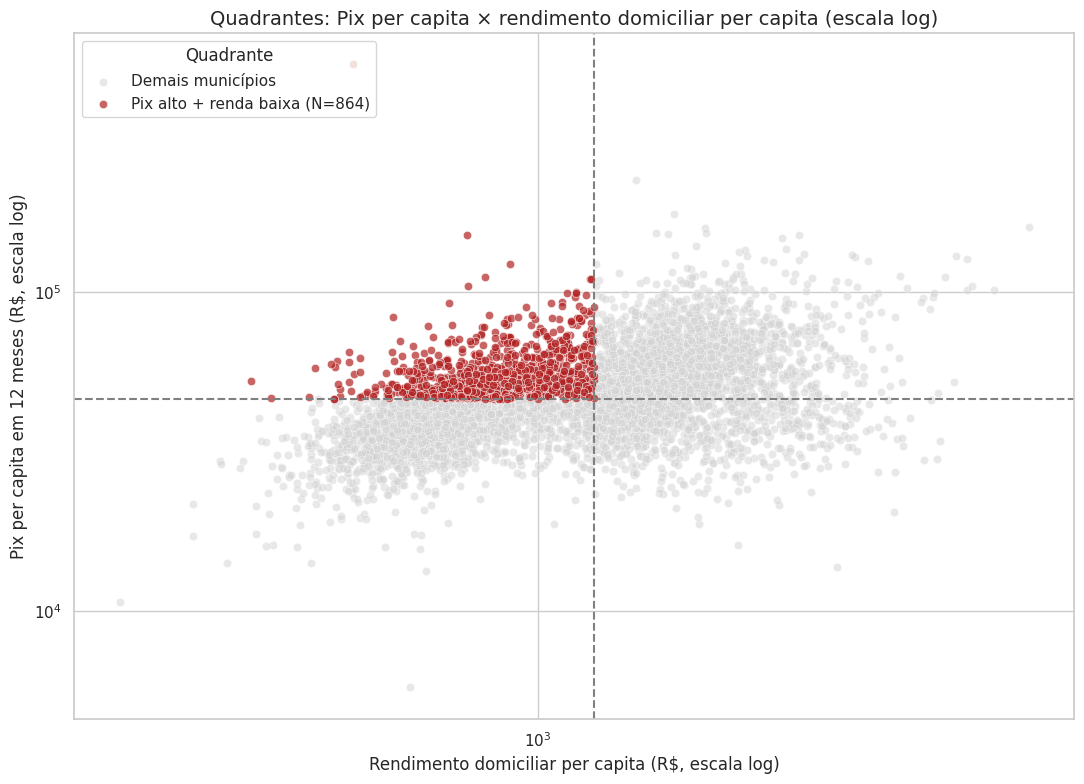

In [8]:
# Quadrantes: Pix per capita × rendimento domiciliar per capita (escala log)
# Linhas tracejadas marcam as medianas e dividem o plano em 4 quadrantes.
# O quadrante superior-esquerdo (Pix alto + renda baixa) é o grupo de
# "alta adoção Pix e baixa renda" quantificado na célula anterior.

fig, ax = plt.subplots(figsize=(11, 8))

pix_alto_renda_baixa = (df["pix_per_capita_12m"] > mediana_pix) & (
    df["rendimento_domiciliar_per_capita"] < mediana_renda
)

sns.scatterplot(
    data=df[~pix_alto_renda_baixa],
    x="rendimento_domiciliar_per_capita",
    y="pix_per_capita_12m",
    color="lightgray",
    alpha=0.5,
    ax=ax,
    label="Demais municípios",
)
sns.scatterplot(
    data=df[pix_alto_renda_baixa],
    x="rendimento_domiciliar_per_capita",
    y="pix_per_capita_12m",
    color="firebrick",
    alpha=0.7,
    ax=ax,
    label=f"Pix alto + renda baixa (N={pix_alto_renda_baixa.sum():,})",
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.axvline(mediana_renda, color="gray", linestyle="--")
ax.axhline(mediana_pix, color="gray", linestyle="--")
ax.set_title(
    "Quadrantes: Pix per capita × rendimento domiciliar per capita (escala log)",
    fontsize=14,
)
ax.set_xlabel("Rendimento domiciliar per capita (R$, escala log)", fontsize=12)
ax.set_ylabel("Pix per capita em 12 meses (R$, escala log)", fontsize=12)
ax.legend(title="Quadrante", loc="upper left")

plt.tight_layout()
save_figure(fig, "02_quadrante_pix_renda.png")
plt.show()

In [9]:
report = {
    "estatisticas_por_estrato": stats.to_dict(),
    "municipios_alto_pix_baixa_renda": int(len(df_oportunidade)),
}
save_json(report, "02_economia_dinamismo.json")

2026-09-03 12:18:45,239 - INFO - JSON salvo em /home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/data/processed/reports/02_economia_dinamismo.json


PosixPath('/home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/data/processed/reports/02_economia_dinamismo.json')

## Resumo Executivo

Este notebook gerou o relatório `02_economia_dinamismo.json`. Abaixo segue um resumo legível dos principais resultados.

In [10]:
# Resumo legível do relatório gerado
import json
from pathlib import Path

report_path = Path.cwd().parents[1] / "data/processed/reports/02_economia_dinamismo.json"
if report_path.exists():
    with open(report_path, "r", encoding="utf-8") as f:
        report = json.load(f)
    print(json.dumps(report, indent=2, ensure_ascii=False))
else:
    print("Relatório ainda não foi gerado.")

{
  "estatisticas_por_estrato": {
    "rendimento_domiciliar_per_capita": {
      "pequena": 1145.36,
      "media": 1460.71,
      "grande": 2079.68
    },
    "pib_per_capita": {
      "pequena": 28216.86,
      "media": 42068.32,
      "grande": 56227.29
    },
    "pix_per_capita_12m": {
      "pequena": 44655.74,
      "media": 61497.72,
      "grande": 83289.65
    }
  },
  "municipios_alto_pix_baixa_renda": 864
}
